In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")

In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Rows: 9471
Columns: 17

Column Names:
Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

Data Types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object


In [ ]:
df = df.dropna(axis=1, how="all")

print("New shape:", df.shape)

New shape: (9471, 15)


In [ ]:
df = df.replace(-200, np.nan)

In [ ]:
print(df.isnull().sum())

Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64


In [ ]:
# Convert time from 18.00.00 format to 18:00:00
df["Time"] = df["Time"].str.replace(".", ":", regex=False)

# Combine Date and Time
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

# Display the result
df[["Date", "Time", "Datetime"]].head()

,Date,Time,Datetime
0,10/03/2004,18:00:00,2004-03-10 18:00:00
1,10/03/2004,19:00:00,2004-03-10 19:00:00
2,10/03/2004,20:00:00,2004-03-10 20:00:00
3,10/03/2004,21:00:00,2004-03-10 21:00:00
4,10/03/2004,22:00:00,2004-03-10 22:00:00


In [ ]:
df = df.sort_values("Datetime")
df = df.reset_index(drop=True)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].interpolate()

df = df.dropna(subset=["CO(GT)", "T", "RH"])

print(df[["CO(GT)", "T", "RH"]].isnull().sum())

CO(GT)    0
T         0
RH        0
dtype: int64


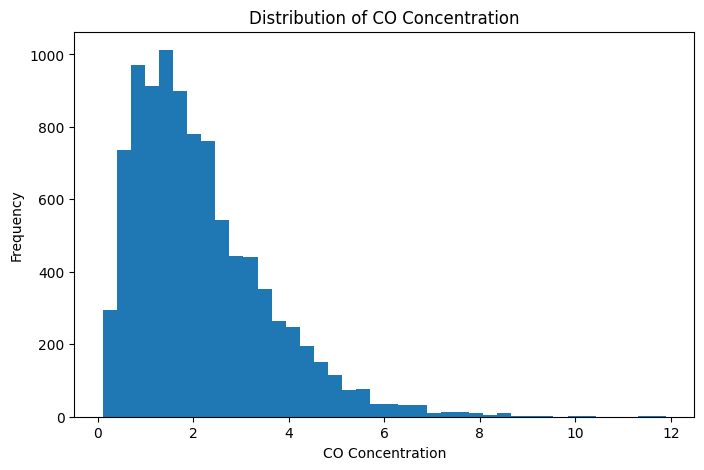

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["CO(GT)"], bins=40)

plt.title("Distribution of CO Concentration")
plt.xlabel("CO Concentration")
plt.ylabel("Frequency")

plt.show()

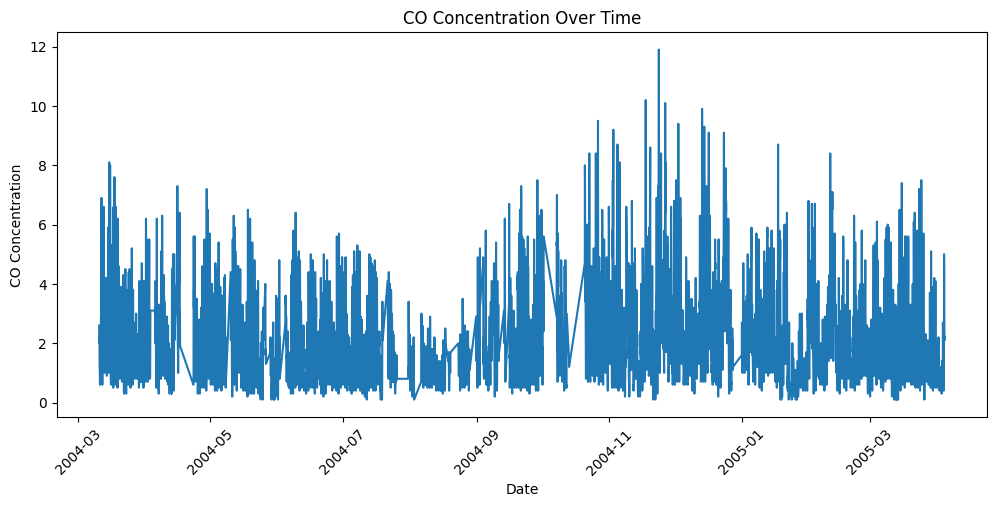

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Datetime"], df["CO(GT)"])

plt.title("CO Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("CO Concentration")

plt.xticks(rotation=45)
plt.show()

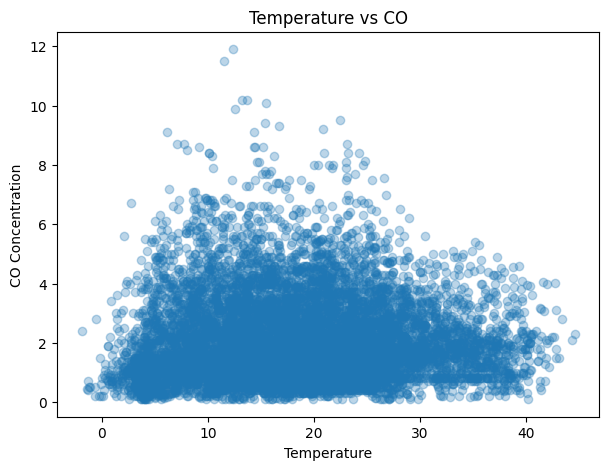

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df["T"], df["CO(GT)"], alpha=0.3)

plt.title("Temperature vs CO")
plt.xlabel("Temperature")
plt.ylabel("CO Concentration")

plt.show()

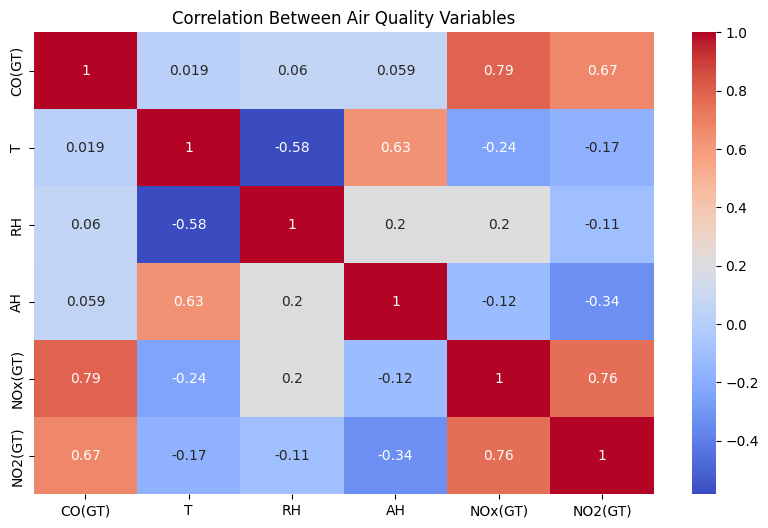

In [ ]:
plt.figure(figsize=(10,6))

corr = df[["CO(GT)", "T", "RH", "AH", "NOx(GT)", "NO2(GT)"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Air Quality Variables")

plt.show()

In [ ]:
df["CO_lag1"] = df["CO(GT)"].shift(1)

df["Hour"] = df["Datetime"].dt.hour

df["DayOfWeek"] = df["Datetime"].dt.dayofweek

In [ ]:
df["Target"] = df["CO(GT)"].shift(-1)

In [ ]:
data = df[
    ["CO_lag1", "T", "RH", "Hour", "DayOfWeek", "Target"]
].dropna()

print("Model data shape:", data.shape)

Model data shape: (9356, 6)


In [ ]:
X = data[
    ["CO_lag1", "T", "RH", "Hour", "DayOfWeek"]
]

y = data["Target"]

print("X:", X.shape)
print("y:", y.shape)

X: (9356, 5)
y: (9356,)


In [ ]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (7484, 5)
Testing: (1872, 5)


In [ ]:
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION")
print("----------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

MODEL EVALUATION
----------------
MAE  : 0.5900217918513896
MSE  : 0.7235565819811974
RMSE : 0.8506212917516216
R2   : 0.6205173827028181


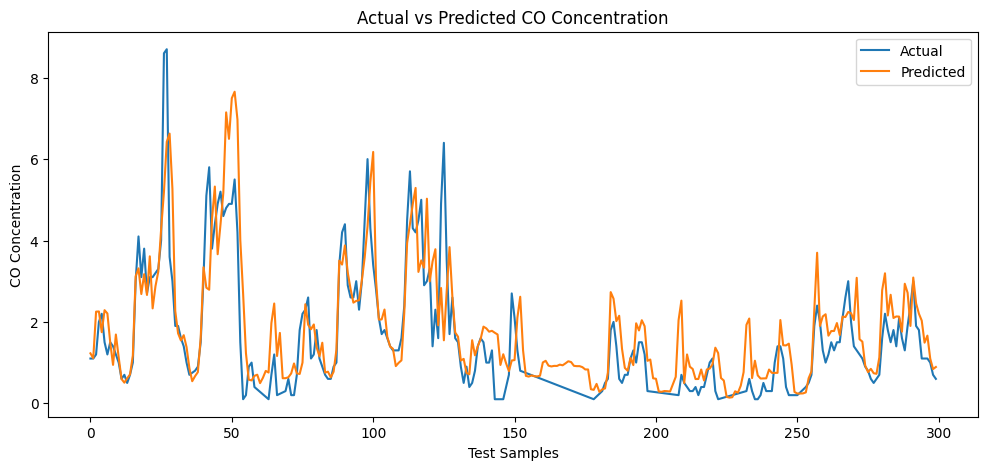

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")

plt.title("Actual vs Predicted CO Concentration")
plt.xlabel("Test Samples")
plt.ylabel("CO Concentration")

plt.legend()
plt.show()

In [ ]:
error = y_test.values - y_pred

print("Average Absolute Error:", np.mean(np.abs(error)))
print("Maximum Error:", np.max(np.abs(error)))

Average Absolute Error: 0.5900217918513896
Maximum Error: 4.967714285714284


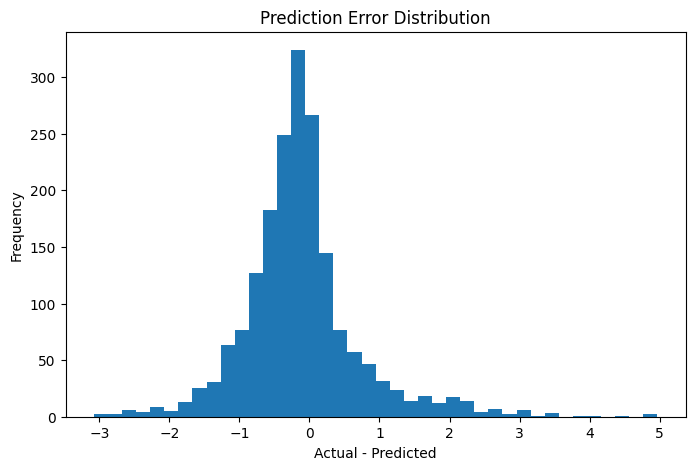

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(error, bins=40)

plt.title("Prediction Error Distribution")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Absolute_Error"] = abs(
    results["Actual"] - results["Predicted"]
)

results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Absolute_Error
1612,7.5,2.532286,4.967714
125,6.4,1.547900,4.852100
604,8.4,3.916000,4.484000
617,5.9,1.827668,4.072332
868,6.3,2.483600,3.816400
26,8.6,5.192000,3.408000
435,6.4,3.022000,3.378000
748,5.6,2.228000,3.372000
1397,5.7,2.524000,3.176000
434,6.7,3.574937,3.125063


In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

CO_lag1      0.523818
Hour         0.228540
RH           0.095514
T            0.087270
DayOfWeek    0.064857
dtype: float64


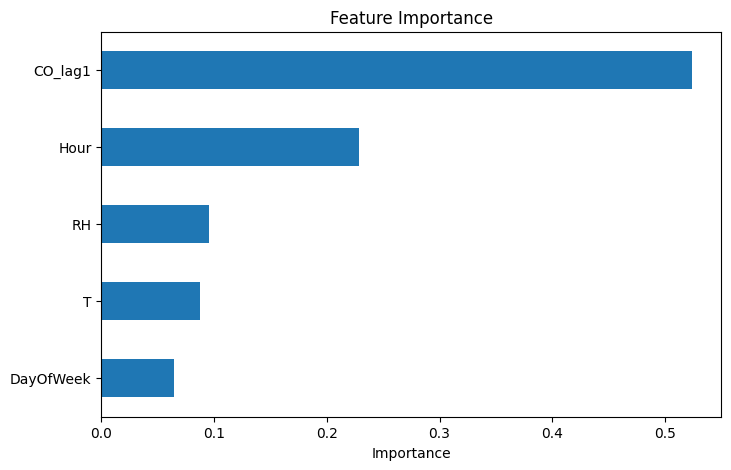

In [ ]:
plt.figure(figsize=(8,5))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

## Data Leakage

Data leakage occurs when information from the future is accidentally used while training a machine-learning model.

This is especially important for time-series forecasting.

In this project, data leakage was avoided by keeping the observations in chronological order. The first 80% of the data was used for training and the final 20% was used for testing.

The `CO_lag1` feature represents the previous CO measurement, while `Target` represents the next CO measurement. Therefore, the model uses past information to predict a future value rather than using the future target as an input.

# Key Findings

1. CO concentration varies considerably over time, showing that air quality changes across different periods.

2. Previous CO concentration is useful for predicting the next CO concentration because air-quality measurements have a time-dependent relationship.

3. Temperature and relative humidity provide additional information for predicting future CO concentration.

4. The hour of the day helps the model capture daily patterns in air quality.

5. The Random Forest model was able to predict future CO concentration using historical and environmental features.

6. The model performs better for observations where the CO concentration changes gradually and produces larger errors when the concentration changes suddenly.

7. The model performance was evaluated using MAE, MSE, RMSE and R².

# Limitations

1. The model predicts only CO concentration and does not predict all air pollutants.

2. The model was trained and tested using data from the same dataset and location, so the results may not generalize to other locations.

3. Random Forest does not explicitly model long-term temporal dependencies like specialized time-series models such as LSTM.

# Future Improvements

The project could be improved by:

- Adding more lag and rolling-average features.
- Testing additional machine-learning models such as Gradient Boosting or XGBoost.
- Using hyperparameter tuning to improve the model.
- Testing advanced time-series models such as LSTM.
- Testing the model on air-quality data from another location.

# Conclusion

This project analysed the UCI Air Quality Dataset and developed a machine-learning model to predict future CO concentration.

The dataset was cleaned by replacing invalid -200 values, handling missing values, and processing the date and time information.

Exploratory data analysis was performed to understand the distribution of CO, changes over time, and relationships between air-quality variables.

Feature engineering was performed using previous CO measurements and time-based features such as hour and day of the week.

A chronological 80-20 train-test split was used to prevent future information from entering the training data. A Random Forest Regressor was then trained and evaluated using MAE, MSE, RMSE and R².

The project demonstrates a complete machine-learning workflow from data preprocessing and exploratory analysis to prediction, evaluation, and interpretation.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION")
print("----------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

MODEL EVALUATION
----------------
MAE  : 0.5900217918513896
MSE  : 0.7235565819811974
RMSE : 0.8506212917516216
R2   : 0.6205173827028181


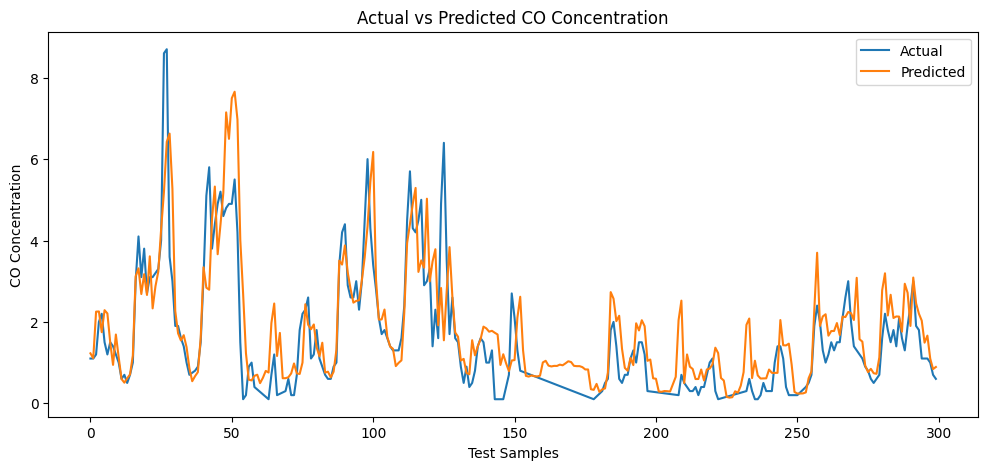

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")

plt.title("Actual vs Predicted CO Concentration")
plt.xlabel("Test Samples")
plt.ylabel("CO Concentration")
plt.legend()
plt.show()

CO_lag1      0.523818
Hour         0.228540
RH           0.095514
T            0.087270
DayOfWeek    0.064857
dtype: float64


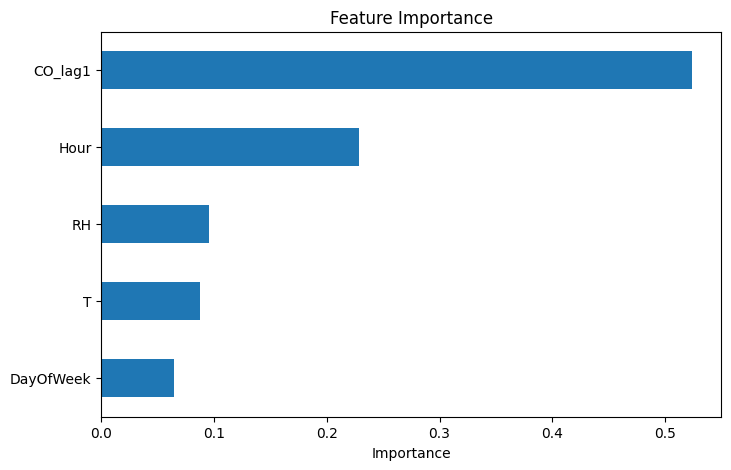

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()